In [29]:
!git clone https://github.com/Mikayla-ds2/surge-sense.git

Cloning into 'surge-sense'...
remote: Enumerating objects: 126, done.
remote: Counting objects: 100% (126/126), done.
remote: Compressing objects: 100% (100/100), done.
remote: Total 126 (delta 60), reused 86 (delta 25), pack-reused 0 (from 0)
Receiving objects: 100% (126/126), 4.27 MiB | 23.40 MiB/s, done.
Resolving deltas: 100% (60/60), done.


In [30]:
# dependecies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
data = pd.read_csv('/content/drive/MyDrive/cleaned-data.csv')

data = data.drop(['Unnamed: 0'], axis=1)

data.head()

,patient_id,patient_gender,patient_race,patient_age,admission_day,admission_time,patient_waittime,admission_flag,department_referral,age_category,time_category,day_of_week
0,145-39-5406,Male,White,69,2024-03-20,08:47:00,39,False,No referral.,Senior,Day,Wednesday
1,316-34-3057,Male,Native American/Alaska Native,4,2024-06-15,11:29:00,27,True,No referral.,Minor,Day,Saturday
2,897-46-3852,Female,African American,56,2024-06-20,09:13:00,55,True,General Practice,Older Adult,Day,Thursday
3,358-31-9711,Female,Native American/Alaska Native,24,2024-04-02,22:34:00,31,True,General Practice,Young Adult,Evening,Tuesday
4,289-26-0537,Male,African American,5,2024-04-09,17:48:00,10,False,Orthopedics,Minor,Evening,Tuesday


In [33]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9216 entries, 0 to 9215
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   patient_id           9216 non-null   object
 1   patient_gender       9216 non-null   object
 2   patient_race         9216 non-null   object
 3   patient_age          9216 non-null   int64 
 4   admission_day        9216 non-null   object
 5   admission_time       9216 non-null   object
 6   patient_waittime     9216 non-null   int64 
 7   admission_flag       9216 non-null   bool  
 8   department_referral  9216 non-null   object
 9   age_category         9216 non-null   object
 10  time_category        9216 non-null   object
 11  day_of_week          9216 non-null   object
dtypes: bool(1), int64(2), object(9)
memory usage: 801.1+ KB


In [34]:
data.describe()

,patient_age,patient_waittime
count,9216.000000,9216.000000
mean,39.855143,35.259874
std,22.755125,14.735323
min,1.000000,10.000000
25%,20.000000,23.000000
50%,39.000000,35.000000
75%,60.000000,48.000000
max,79.000000,60.000000


In [35]:
data.isnull().sum()

,0
patient_id,0
patient_gender,0
patient_race,0
patient_age,0
admission_day,0
admission_time,0
patient_waittime,0
admission_flag,0
department_referral,0
age_category,0


In [36]:
data.duplicated().sum()

np.int64(0)

In [37]:
data.shape

(9216, 12)

In [38]:
import seaborn as sns
from matplotlib.colors import ListedColormap

In [39]:
# for all my plots
palette = ['#EAD3A9', '#84592B', '#A05135',
           '#743015', '#462D1B', '#9D9368']
customcmap = ListedColormap(palette)

/tmp/ipykernel_3390/2111218608.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 1200x700 with 0 Axes>

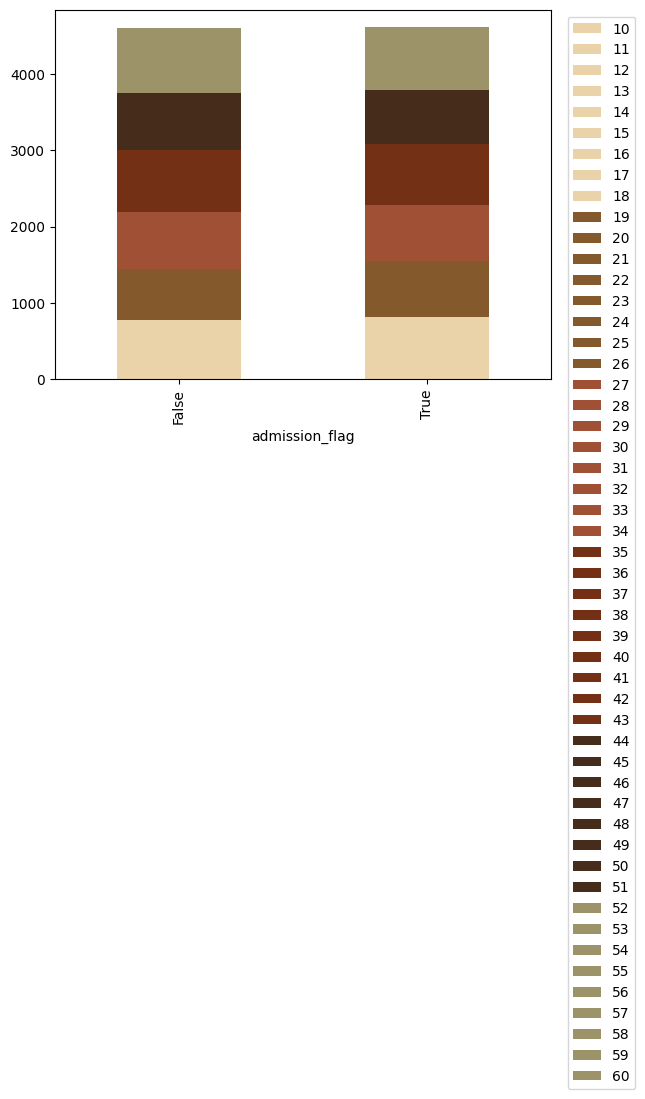

In [40]:
# creating cross table to evaluate if admission is a valuable variable
crosstab01 = pd.crosstab(data['admission_flag'],
                         data['patient_waittime'])

plt.figure(figsize=(12, 7))
crosstab01.plot(kind='bar', stacked=True, colormap=customcmap)
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

In [41]:
# determined by the previous images, admission_flag
# has inconclusive context and
# thus need to be excluded from any further analysis or modeling.
data = data.drop(['admission_flag'], axis=1)
data.head()

,patient_id,patient_gender,patient_race,patient_age,admission_day,admission_time,patient_waittime,department_referral,age_category,time_category,day_of_week
0,145-39-5406,Male,White,69,2024-03-20,08:47:00,39,No referral.,Senior,Day,Wednesday
1,316-34-3057,Male,Native American/Alaska Native,4,2024-06-15,11:29:00,27,No referral.,Minor,Day,Saturday
2,897-46-3852,Female,African American,56,2024-06-20,09:13:00,55,General Practice,Older Adult,Day,Thursday
3,358-31-9711,Female,Native American/Alaska Native,24,2024-04-02,22:34:00,31,General Practice,Young Adult,Evening,Tuesday
4,289-26-0537,Male,African American,5,2024-04-09,17:48:00,10,Orthopedics,Minor,Evening,Tuesday


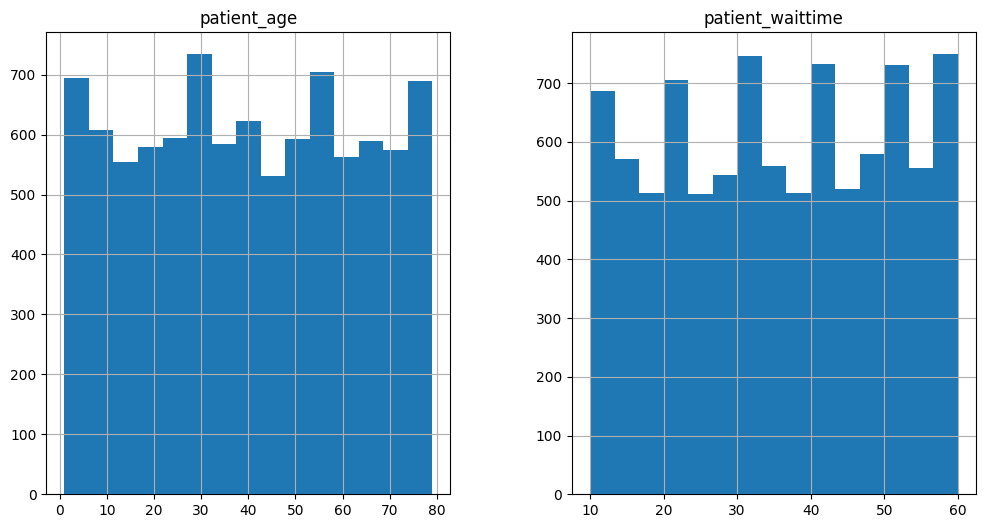

In [42]:
histogram = data.select_dtypes(
    include=['number', 'bool']).hist(bins=15, figsize=[12, 6])
plt.show()

In [43]:
%cd surge-sense
from deviation import test_deviation
#from plot_deviation import plot_diverging_plot, plot_confidence_heatmap

/content/surge-sense/surge-sense


In [50]:
%pip install "pywaffle[icons]" 
from pywaffle import Waffle

In [45]:
deviation_data = data[data['department_referral'] != 'No referral.']
deviation_data.head()

,patient_id,patient_gender,patient_race,patient_age,admission_day,admission_time,patient_waittime,department_referral,age_category,time_category,day_of_week
2,897-46-3852,Female,African American,56,2024-06-20,09:13:00,55,General Practice,Older Adult,Day,Thursday
3,358-31-9711,Female,Native American/Alaska Native,24,2024-04-02,22:34:00,31,General Practice,Young Adult,Evening,Tuesday
4,289-26-0537,Male,African American,5,2024-04-09,17:48:00,10,Orthopedics,Minor,Evening,Tuesday
10,497-14-6812,Female,White,73,2024-07-26,01:45:00,34,Gastroenterology,Senior,Night,Friday
11,393-38-9502,Female,White,16,2024-10-03,22:02:00,39,Orthopedics,Minor,Evening,Thursday


In [46]:
result = test_deviation(
    data=deviation_data,
    feature='day_of_week',
    outcome='department_referral'
)
result.tidy

,day_of_week,department_referral,observed_count,expected_count,pct,diff_pp,adjusted_residual,baseline_pct,low_reliability,significant
0,Friday,Cardiology,37,32.754717,7.341270,0.842318,0.823418,6.498952,False,False
1,Friday,Gastroenterology,20,23.509434,3.968254,-0.696316,-0.795697,4.664570,False,False
2,Friday,General Practice,231,243.018868,45.833333,-2.384696,-1.150041,48.218029,False,False
3,Friday,Neurology,37,25.490566,7.341270,2.283618,2.511269,5.057652,False,False
4,Friday,Orthopedics,133,131.415094,26.388889,0.314465,0.172601,26.074423,False,False
5,Friday,Physiotherapy,40,36.452830,7.936508,0.703804,0.654754,7.232704,False,False
6,Friday,Renal,6,11.358491,1.190476,-1.063193,-1.726199,2.253669,False,False
7,Monday,Cardiology,30,37.628931,5.181347,-1.317605,-1.396456,6.498952,False,False
8,Monday,Gastroenterology,35,27.007862,6.044905,1.380335,1.710108,4.664570,False,False
9,Monday,General Practice,278,279.182390,48.013817,-0.204212,-0.106773,48.218029,False,False


In [47]:
result.summary()

,Deviation test
Chi-squared statistic,42.397931
p-value,0.214462
Degrees of Freedom,36.000000
Number of cells,49.000000
Bonferroni alpha,0.001020
Critical z-score,3.284839


In [48]:
result.table

department_referral,Cardiology,Gastroenterology,General Practice,Neurology,Orthopedics,Physiotherapy,Renal
day_of_week,,,,,,,
Friday,7.341270,3.968254,45.833333,7.341270,26.388889,7.936508,1.190476
Monday,5.181347,6.044905,48.013817,4.317789,25.388601,8.290155,2.763385
Saturday,6.725664,4.601770,50.619469,4.601770,25.486726,6.548673,1.415929
Sunday,6.031128,4.669261,46.108949,4.863813,29.766537,6.420233,2.140078
Thursday,7.156309,5.461394,47.834275,4.896422,27.495292,5.838041,1.318267
Tuesday,6.914894,4.078014,49.822695,5.141844,22.695035,7.269504,4.078014
Wednesday,6.261181,3.756708,48.837209,4.472272,25.760286,8.228980,2.683363


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


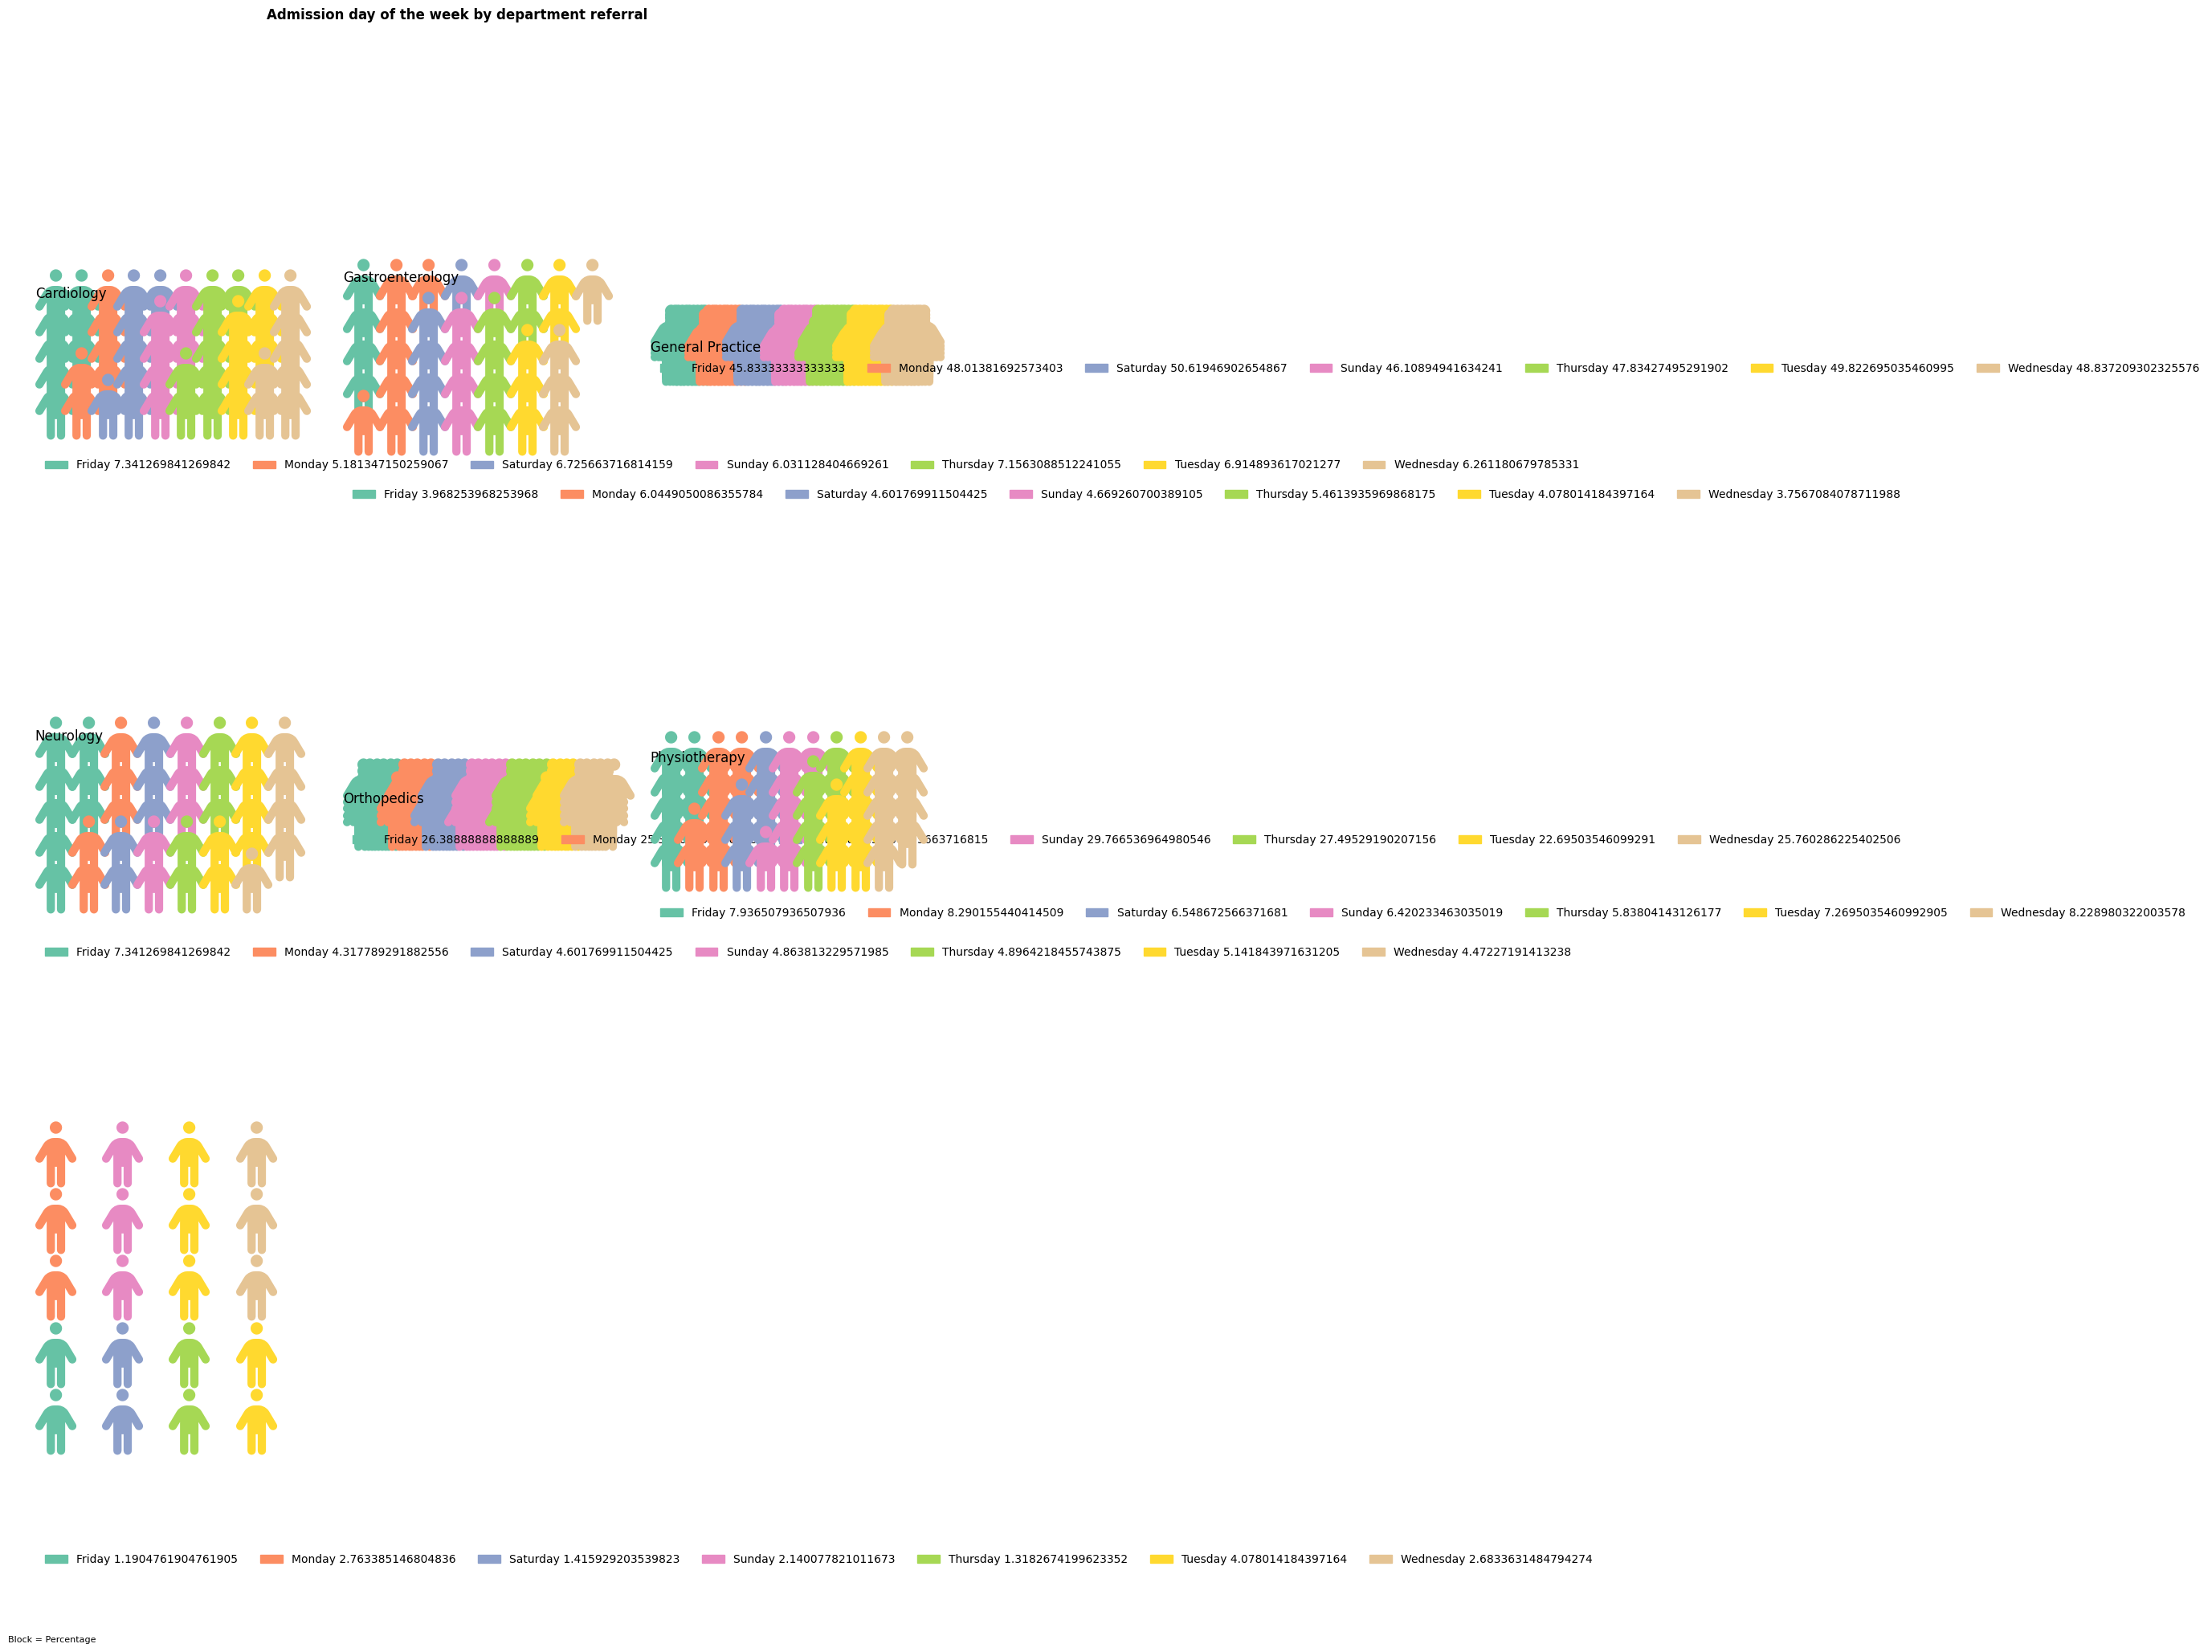

In [64]:
plot_data = result.table

fig = plt.figure(
    FigureClass=Waffle,
    plots = {
        331: { # so those numbers actually meant something: 311 = 3 rows 1 column subplot 1/2/3
            'values': plot_data['Cardiology'],
            'labels': [f"{k} {v}" for k, v in plot_data['Cardiology'].items()],
            'legend': {'loc': 'lower left', 'bbox_to_anchor': (0, -0.4), 'ncol': len(plot_data), 'framealpha': 0},
            'starting_location': 'NW',
            # add icons after dictionaries, especially since i wanna use the same icons for all plots
            'title': {'label': 'Cardiology', 'loc': 'left'}
        },
        332: {
            'values': plot_data['Gastroenterology'],
            'labels': [f"{k} {v}" for k, v in plot_data['Gastroenterology'].items()],
            'legend': {'loc': 'lower left', 'bbox_to_anchor': (0, -0.4), 'ncol': len(plot_data), 'framealpha': 0},
            'starting_location': 'NW',
            'title': {'label': 'Gastroenterology', 'loc': 'left'}            
        },
        333: {
            'values': plot_data['General Practice'],
            'labels': [f"{k} {v}" for k, v in plot_data['General Practice'].items()],
            'legend': {'loc': 'lower left', 'bbox_to_anchor': (0, -0.4), 'ncol': len(plot_data), 'framealpha': 0},
            'starting_location': 'NW',
            'title': {'label': 'General Practice', 'loc': 'left'}
        },
        334: {
            'values': plot_data['Neurology'],
            'labels': [f"{k} {v}" for k, v in plot_data['Neurology'].items()],
            'legend': {'loc': 'lower left', 'bbox_to_anchor': (0, -0.4), 'ncol': len(plot_data), 'framealpha': 0},
            'starting_location': 'NW',
            'title': {'label': 'Neurology', 'loc': 'left'}
        },
        335: {
            'values': plot_data['Orthopedics'],
            'labels': [f"{k} {v}" for k, v in plot_data['Orthopedics'].items()],
            'legend': {'loc': 'lower left', 'bbox_to_anchor': (0, -0.4), 'ncol': len(plot_data), 'framealpha': 0},
            'starting_location': 'NW',
            'title': {'label': 'Orthopedics', 'loc': 'left'}
        },
        336: {
            'values': plot_data['Physiotherapy'],
            'labels': [f"{k} {v}" for k, v in plot_data['Physiotherapy'].items()],
            'legend': {'loc': 'lower left', 'bbox_to_anchor': (0, -0.4), 'ncol': len(plot_data), 'framealpha': 0},
            'starting_location': 'NW',
            'title': {'label': 'Physiotherapy', 'loc': 'left'}
        },
        337: {
            'values': plot_data['Renal'],
            'labels': [f"{k} {v}" for k, v in plot_data['Renal'].items()],
            'legend': {'loc': 'lower left', 'bbox_to_anchor': (0, -0.4), 'ncol': len(plot_data), 'framealpha': 0},
        },
    },
    icons='person',
    rows=5,
    # need to add to palette for the number of plots
    rounding_rule='ceil',
    figsize=(14, 21)
)

fig.suptitle('Admission day of the week by department referral', fontweight='bold')
fig.supxlabel('Block = Percentage', fontsize=8, x=0.14)

plt.show()

In [ ]:
plot_data = result.table  # days as rows (index), departments as columns, each row ~100%

departments = plot_data.columns.tolist()
days = plot_data.index.tolist()

# One fixed color per day, defined ONCE, so the same day reads as the
# same color in every department's panel. This is the fix for the
# "same day, different color per subplot" problem in the original --
# without this dict, pywaffle's default color cycle restarts fresh
# for each subplot's own category list.
day_color_map = {
    "Monday": "#4C72B0",
    "Tuesday": "#DD8452",
    "Wednesday": "#55A868",
    "Thursday": "#C44E52",
    "Friday": "#8172B2",
    "Saturday": "#937860",
    "Sunday": "#DA8BC3",
}
# Reorder to match plot_data's actual column order, in case your
# crosstab's columns aren't in Mon-Sun order.
day_color_map = {day: day_color_map[day] for day in days}

# Build one subplot spec per department. Using 330 + i keeps the same
# 3-row-by-3-column layout as your original (331..337), just generated
# instead of hand-typed -- which is also what caught the missing
# 'title' key on the 7th (Renal) subplot in your version.
plots = {}
for i, dept in enumerate(departments, start=1):
    series = plot_data[dept]  # column-select, since dept is a column name here
    plots[330 + i] = {
        "values": series,
        # Colors pulled from the shared map, in THIS subplot's own
        # category order -- keeps colors consistent even if a given
        # department happens to have missing/zero values for some day.
        "colors": [day_color_map[day] for day in series.index],
        # Rounded to 1 decimal instead of the raw float -- this is
        # what was producing "Friday 45.83333333333" in your labels.
        "labels": [f"{day} ({pct:.1f}%)" for day, pct in series.items()],
        "title": {"label": dept, "loc": "left", "fontsize": 11},
        "starting_location": "NW",
        # No per-subplot 'legend' key -- removed entirely. Seven
        # separate legends, each anchored relative to its own small
        # subplot, is what was overlapping into neighboring panels.
        # One shared legend is built for the whole figure instead,
        # after the figure is created (below).
    }

fig = plt.figure(
    FigureClass=Waffle,
    plots=plots,
    rows=5,
    rounding_rule="ceil",
    # No 'icons' parameter -- plain colored blocks. Reliable across
    # environments, and arguably clearer for reading percentages than
    # icons would have been anyway.
    figsize=(14, 16),  # shorter than the original 21in tall figure;
                        # tall figures made per-panel legend math (the
                        # -0.4 bbox_to_anchor) behave inconsistently
                        # across panels of different sizes.
)

# ONE legend for the entire figure, built manually from the same
# color map every panel used -- guaranteed to match every panel
# exactly, since it's built from the same dict, not recomputed per
# subplot.
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=color) for color in day_color_map.values()
]
fig.legend(
    legend_handles,
    day_color_map.keys(),
    loc="lower center",
    ncol=len(day_color_map),
    bbox_to_anchor=(0.5, -0.02),
    frameon=False,
)

fig.suptitle(
    "Admission day of the week by department referral", fontweight="bold", y=0.98
)
fig.supxlabel("Block = Percentage", fontsize=8, x=0.14, y=0.01)

# rect= leaves room at the bottom for the shared legend and at the top
# for the suptitle, instead of letting tight_layout claim that space
# for the subplots themselves.
plt.tight_layout(rect=[0, 0.04, 1, 0.96])
plt.show()

In [ ]:
fig1 = plot_diverging_plot(result=result, feature='day_of_week', outcome=
                           'department_referral')
fig2 = plot_confidence_heatmap(result, feature='day_of_week', outcome=
                               'department_referral')
plt.show()

In [ ]:
from pathlib import Path
features = [
    'patient_race',
    'patient_gender',
    'age_category',
    'time_category',
    'day_of_week'
]

outcome = 'department_referral'
plot_dir = Path('rate_deviation_plots')
plot_dir.mkdir(exist_ok=True)

results = {}
ranking_rows = []


for feature in features:
    result = test_deviation(
        data=data,
        feature=feature,
        outcome=outcome,
        exclude_value='No referral.',
    )
    results[feature] = result
    
    fig = plot_diverging_plot(
        result=result,
        feature=feature,
        outcome=outcome,
    )
    fig.savefig(
        plot_dir / f'{feature}_diverging.png',
        dpi=200,
        bbox_inches='tight',
    )
    plt.close(fig)
    
    fig = plot_confidence_heatmap(
        result=result,
        feature=feature,
        outcome=outcome,
    )
    fig.savefig(
        plot_dir / f'{feature}_confidence_heatmap.png',
        dpi=200,
        bbox_inches='tight',
    )
    plt.close(fig)
    
    ranking_rows.append({
        'feature': feature,
        'chi2_statistic': result.chi2_statistic,
        'p_value': result.chi2_pvalue,
        'degrees_of_freedom': result.dof,
        'significant_cells': 
            result.tidy['significant'].sum(),
        'tested_cells': result.n_cells,
    })
p_value_ranking = (
    pd.DataFrame(ranking_rows)
    .sort_values('p_value', ascending=False)
    .reset_index(drop=True)
)
p_value_ranking

In [ ]:
for feature in features:
    for feature in features:
        result = test_deviation(
            data=data,
            feature=feature,
            outcome=outcome,
            exclude_value='No referral.',
        )
        results[feature] = result

        print(f"\n=== Feature: {feature} ===")
        print(result.summary())

In [ ]:
print(data['patient_race'].unique())
print(data['department_referral'].unique())

In [ ]:
data['patient_race'].value_counts(normalize=True)

In [ ]:
# this code allows me to only see the people who were referred to a department
referred = data.loc[data[
    'department_referral'] != 'No referral.', 'department_referral']

In [ ]:
referred.value_counts(normalize=True)

In [ ]:
data['patient_race'].value_counts(
    normalize=True).mul(100).round(1)

In [ ]:
# is referred but adds race for proper percentage calculations
referrals = data.loc[
    data['department_referral'].ne('No referral.'),
    ['patient_race', 'department_referral']
]

# the percentage of patients of that race referred to that department
crosstab_race_dpt = (
    pd.crosstab(
        referrals['patient_race'],
        referrals['department_referral'],
        normalize='columns' # index means to sums to 100 for the row; columns for the column
    )
    .mul(100)
)
# for index: given a patient is of a certain race, what percentage of their referrals go to each department
# for columns: given a pateint was referred to a certain department, what's the racial breakdown of that department
crosstab_race_dpt.round(1)

In [ ]:
referrals['patient_race'].value_counts(
    normalize=True).mul(100).round(1)

In [ ]:
baseline = (
    referrals['department_referral'].value_counts(
        normalize=True).
    mul(100).
    reindex(crosstab_race_dpt.columns)
)

difference_pp = crosstab_race_dpt.sub(
    baseline, axis='columns')
difference_pp.round(2)

In [ ]:
print(baseline)

In [ ]:
referrals_waittime = data.loc[
    data['department_referral'].ne('No referral.'),
    ['patient_waittime', 'department_referral']
]

In [ ]:
mean_values = referrals_waittime.groupby('department_referral')['patient_waittime'].mean()

plt.figure(figsize=(12, 6))
mean_values.plot(kind='bar', color=customcmap.colors)
plt.title('Average Waittime per Department Referral')
plt.xlabel('Department Referral')
plt.ylabel('Patient Waittime')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
print(data.dtypes)

In [ ]:
data.describe()

In [ ]:
columns = ['patient_race', 'patient_gender', 'age_category', 'day_of_week', 'time_category']
for col in columns:
    mean_values = data.groupby(col)['patient_waittime'].mean()

    plt.figure(figsize=(12, 6))
    mean_values.plot(kind='bar', color=customcmap.colors)
    plt.title(f"Average waittime per {col.capitalize()}")
    plt.xlabel(col.capitalize())
    plt.ylabel('Patient Waittime')
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [ ]:
mean_values = data.groupby('patient_race')['patient_age'].mean()

plt.figure(figsize=(12, 6))
mean_values.plot(kind='bar', color=customcmap.colors)
plt.title('Average Age per Patient Race')
plt.xlabel('Patient Race')
plt.ylabel('Average Age')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
%pip install dython 

In [ ]:
data = data.drop(['patient_id'], axis=1)

In [ ]:
from dython.nominal import associations
associations(data)

none of the correlations meet all criteria for being confounders so Simpson's paradox is unlikely and thus stratifying isn't necessary.